# Project 2: Exploratory Data Analysis (EDA)

## Step 1: Import Libraries

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load Dataset

In [100]:
df = pd.read_excel("Dataset for Data Analytics.xlsx")
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Step 3: Dataset Overview

## Shape

In [67]:
df.shape

(1200, 14)

### Columns

In [68]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='object')

### Information

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

### Missing Values

In [70]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

## Step 4: Descriptive Statistics

This is one of the most important requirements.

In [71]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


### Mean

In [72]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].mean()

Quantity          2.945833
UnitPrice       356.412750
ItemsInCart       5.485000
TotalPrice     1053.968300
dtype: float64

### Median

In [73]:
df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']].median()

Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64

### Count

In [74]:
df.count()

OrderID            1200
Date               1200
CustomerID         1200
Product            1200
Quantity           1200
UnitPrice          1200
ShippingAddress    1200
PaymentMethod      1200
OrderStatus        1200
TrackingNumber     1200
ItemsInCart        1200
CouponCode          891
ReferralSource     1200
TotalPrice         1200
dtype: int64

## Step 5: Analyze Sales

### Total Revenue

In [75]:
total_revenue = df['TotalPrice'].sum()

print(total_revenue)

1264761.96


### Average Order Value

In [76]:
df['TotalPrice'].mean()

np.float64(1053.9683)

### Highest Order

In [77]:
df['TotalPrice'].max()

3456.4

### Lowest Order

In [78]:
df['TotalPrice'].min()

11.39

## Step 6: Product Analysis

### Top Selling Products

In [79]:
top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
top_products.head(10)

Product
Chair      562
Printer    542
Laptop     535
Desk       508
Tablet     497
Monitor    480
Phone      411
Name: Quantity, dtype: int64

### Visualization

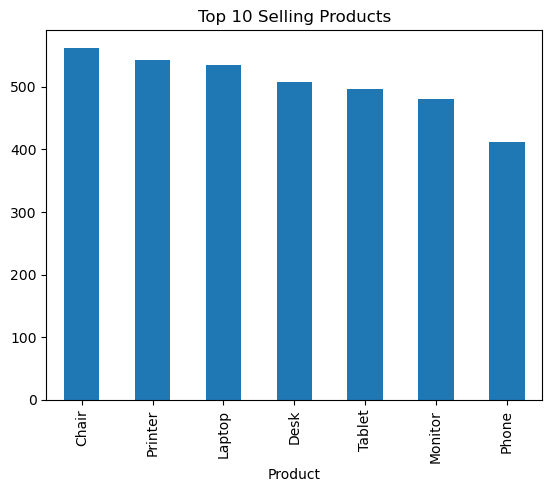

In [80]:
top_products.head(10).plot(kind='bar')

plt.title('Top 10 Selling Products')
plt.show()

## Step 7: Category Analysis

In [81]:
category_sales = df.groupby('Product')['TotalPrice'].sum()
category_sales

Product
Chair      195620.11
Desk       167459.93
Laptop     192126.56
Monitor    175651.41
Phone      151722.39
Printer    195612.61
Tablet     186568.95
Name: TotalPrice, dtype: float64

### Visualization

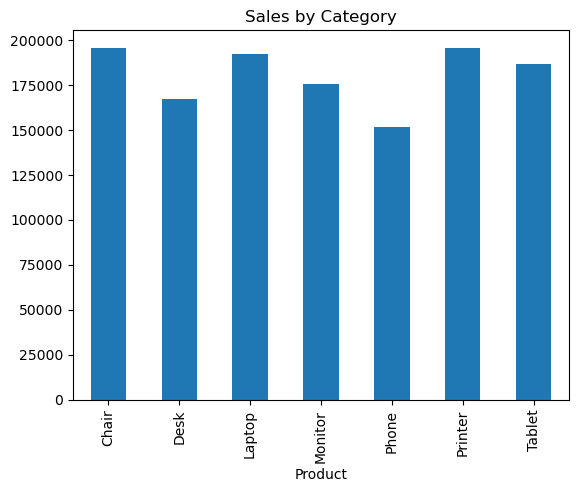

In [82]:
category_sales.plot(kind='bar')

plt.title('Sales by Category')

plt.show()

## Step 8: Payment Method Analysis

In [83]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

### Pie Chart

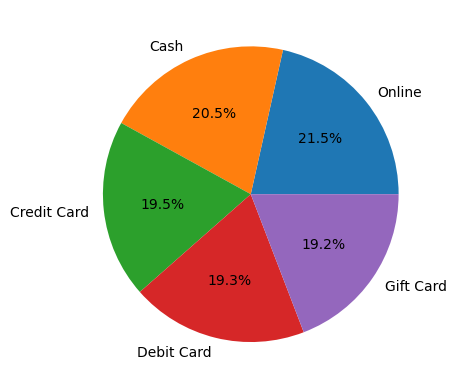

In [84]:
df['PaymentMethod'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.show()

## Step 9: Customer Analysis

### Adresses

In [85]:
df['ShippingAddress'].value_counts().head(10)

ShippingAddress
533 Main St    8
895 Main St    6
146 Main St    5
562 Main St    5
636 Main St    5
696 Main St    5
747 Main St    5
740 Main St    5
154 Main St    4
103 Main St    4
Name: count, dtype: int64

## Step 10: Monthly Trend Analysis

Convert Date:

In [86]:
df['Date'] = pd.to_datetime(df['Date'])

Create Month Column:

In [87]:
df['Month'] = df['Date'].dt.month_name()

### Monthly Sales

In [88]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales

Month
April        109186.05
August        86343.21
December      82540.50
February     112344.78
January      124313.23
July          85784.64
June         170616.13
March        123840.93
May          135142.59
November      75493.43
October       89834.82
September     69321.65
Name: TotalPrice, dtype: float64

### Line Chart

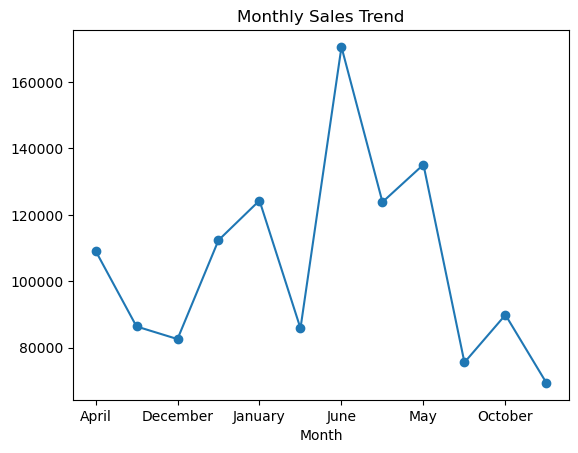

In [89]:
monthly_sales.plot(marker='o')

plt.title('Monthly Sales Trend')

plt.show()

## Step 11: Order Status Analysis

In [90]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

### Chart

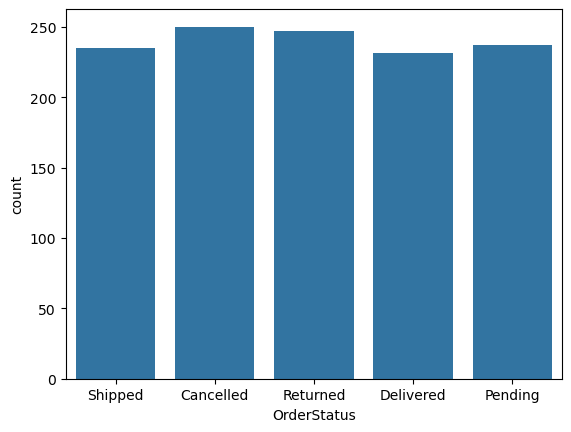

In [91]:
sns.countplot(
    data=df,
    x='OrderStatus'
)

plt.show()

## Step 12: Coupon Analysis

In [97]:
df['CouponCode'].fillna('No Coupon', inplace=True)

In [98]:
df['CouponCode'].fillna('No Coupon', inplace=True)

df['CouponCode'].value_counts().head(10)

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

## Step 13: Outlier Detection

### Boxplot

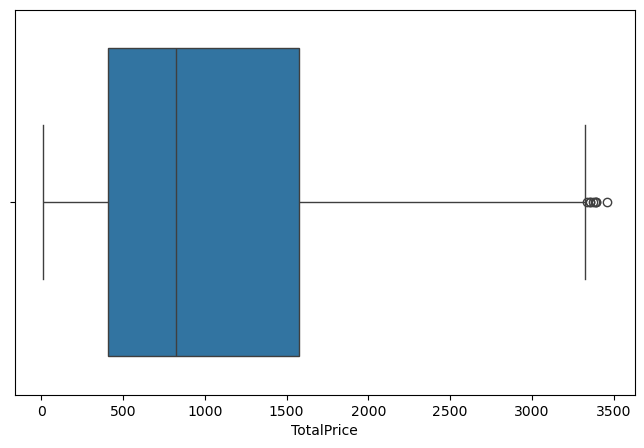

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['TotalPrice'])

plt.show()

### IQR Method

In [94]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df['TotalPrice'] < lower) |
    (df['TotalPrice'] > upper)
]

print(outliers.shape)

(8, 15)


### Heatmap

In [95]:
corr = df[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].corr()

corr

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


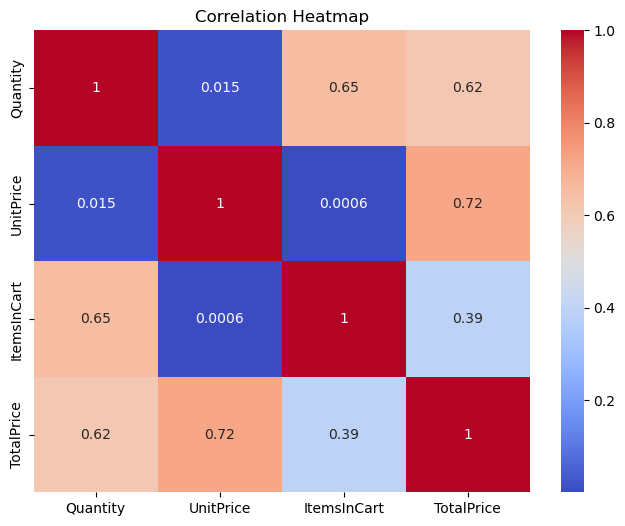

In [96]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

## Step 15: Key Observations

Total dataset contains 1200 records.
CouponCode contains missing values.
No duplicate records found.
Some products generate higher revenue than others.
Certain categories contribute most of the sales.
One payment method is preferred by customers.
Monthly sales show seasonal trends.
A few high-value orders are detected as outliers.
TotalPrice has a strong positive relationship with Quantity.

# Project Conclusion

This Exploratory Data Analysis (EDA) project was conducted to uncover patterns, trends, and insights from the e-commerce dataset. Various statistical techniques and visualizations were used to understand customer behavior, sales performance, product demand, payment preferences, and order trends. The analysis identified key business insights, detected potential outliers, and revealed relationships among important variables. The findings demonstrate how EDA helps transform raw data into meaningful information that supports data-driven decision-making and provides a strong foundation for future predictive analytics and business intelligence projects.